# Inferring Cell–Cell Interactions at a Single Cell Resolution Using Inflow Score

## Background

In this tutorial, we introduce and demonstrate how to compute the **inflow score**,  a novel statistical approach for inferring **cell–cell interactions at single-cell resolution**.
<br>

Inflow score quantifies how much a given cell is *influenced* by neighboring ligand-producing cells through **spatial weighting** of ligand and receptor expression.  
This formulation captures both the **directionality** and **locality** of intercellular signaling, offering a fine-grained view of communication “flows” within spatial transcriptomics data.

<br>


$$
\text{Inflow}_{i,s,\ell,r} =
\left(
\frac{
\sum_{j=1}^{n} W_{ij}\,L_{j,\ell}\,C_{j,s}
}{
\sum_{j=1}^{n} W_{ij}
}
\right)
R_{i,r}
$$

where:

- $W_{ij}$ — spatial connectivity weight between target cell *i* and neighboring cell *j*.
- $L_{j,\ell}$ — expression of ligand $\ell$ in cell *j*.
- $C_{j,s}$ — hard filter, 1 if cell *j* belongs to cell type *s*, otherwise 0. 
- $R_{i,r}$ — expression of receptor *r* in target cell *i*.
- $n$ — total number of cells.

In other words,  Inflow score measures how strongly a cell is **receiving** ligand signals from its spatial neighborhood, accounting for both spatial proximity and cell-type context.


---

## Load Packages

In [ ]:
!! pip install squidpy
!! pip install muon

In [170]:
import numpy as np
import pandas as pd
import scanpy as sc
import plotnine as p9
import liana as li
import muon as mu
import anndata as ad
import matplotlib.pyplot as plt
import squidpy as sq
from liana.method._pipe_utils._common import _get_props
from liana.method.sp._utils import _add_complexes_to_var
from liana._logging import _logg
from liana.method._pipe_utils import prep_check_adata, assert_covered
from scipy.sparse import csr_matrix
from plotnine import scale_y_continuous
from plotnine import geom_vline, annotate
import os
import seaborn as sns
from liana.plotting._plot_spatial_inflow_score_single_interaction import plot_spatial_inflow_score_single_interaction
from liana.plotting._plot_lr_heatmap import lr_heatmap

## Load and Prep Data

To demonstrate the inflow score in practice, we will apply it to a spatial transcriptomics dataset from [*A molecularly defined and spatially resolved cell atlas of the whole mouse brain*(Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

The dataset was generated using **MERFISH** technique, which enables highly multiplexed single-molecule RNA imaging with subcellular spatial resolution. This dataset profiles the expression of more than **1,000 genes** across roughly 10 million cells in the adult **mouse brain**.

In [2]:
file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
backup_url = "https://datasets.cellxgene.cziscience.com/9d118c20-7652-4fb2-ba87-ae59e53ce9ae.h5ad"

if os.path.exists(file_path):
    adata = sc.read(file_path)
else:
    adata = sc.read(
    file_path,
    backup_url=backup_url
)

In [3]:
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.034"]

## Basic QC

In [4]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

/home/alsayah/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [6]:
#Convert ENSEMBLE IDs to SYMBOL
import mygene
mg = mygene.MyGeneInfo()
query = mg.querymany(adata.var_names.tolist(),
                     scopes="ensembl.gene",
                     fields="symbol",
                     species="mouse")

# Make a mapping dictionary {ensembl_id: symbol}
mapping = {q['query']: q.get('symbol', q['query']) for q in query}
adata.var_names = [mapping.get(gid, gid) for gid in adata.var_names]

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


querying 1-1000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 1001-1122 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
Finished.
2 input query terms found no hit:	['ENSMUSG00000109473', 'ENSMUSG00000113186']
Pass "returnall=True" to return complete lists of duplicate or missing query terms.


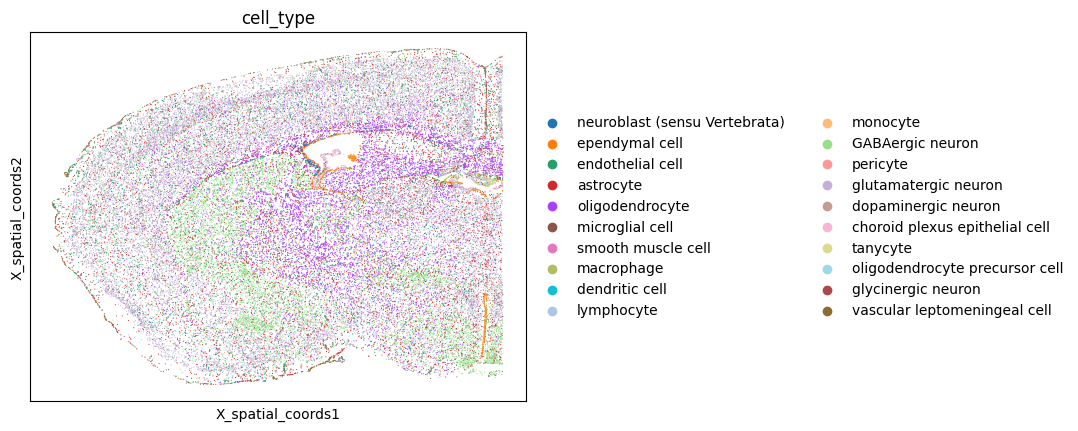

In [7]:
sc.pl.embedding(adata, basis="X_spatial_coords", color="cell_type")

## Calculate spatial connectivity matrix Wij

Before calculating the inflow score, we first need to define the **spatial connectivity matrix** $W_{ij}$, which encodes how strongly each cell $i$ is connected to its spatial neighbors $j$.
In essence, $W_{ij}$ determines the *neighborhood* over which ligand signals are integrated, it specifies *who can talk to whom* in the tissue space.


### Choosing the right bandwith

To compute $W_{ij}$, we typically use a **spatial kernel** (e.g., Gaussian or distance-based) with a parameter called the **bandwidth** ($h$), which controls the spatial scale of interactions:

- A **small bandwidth** captures only very **local** interactions (e.g., direct cell–cell contacts).  
- A **large bandwidth** allows **broader** neighborhoods, integrating ligand signals from more distant cells.  

Choosing the right bandwidth is therefore crucial:  
- **Biologically**, it should reflect the *typical range of molecular signaling* in the tissue.  
  For example, some ligands act only on adjacent cells (juxtacrine or short-range paracrine), while others diffuse more broadly through the extracellular space.  
- **Technically**, the optimal bandwidth also depends on the **spatial resolution**. <br>
    Because inflow score works at **single-cell resolution**, using too wide a bandwidth could blur fine spatial patterns, whereas too narrow a bandwidth might miss biologically relevant signaling gradients.  

In this step, you can explore different bandwidth values and examine how many neighbors each cell would have at each scale using  
`li.ut.query_bandwidth()`. This helps visualize the trade-off between **spatial resolution** and **neighborhood size**.

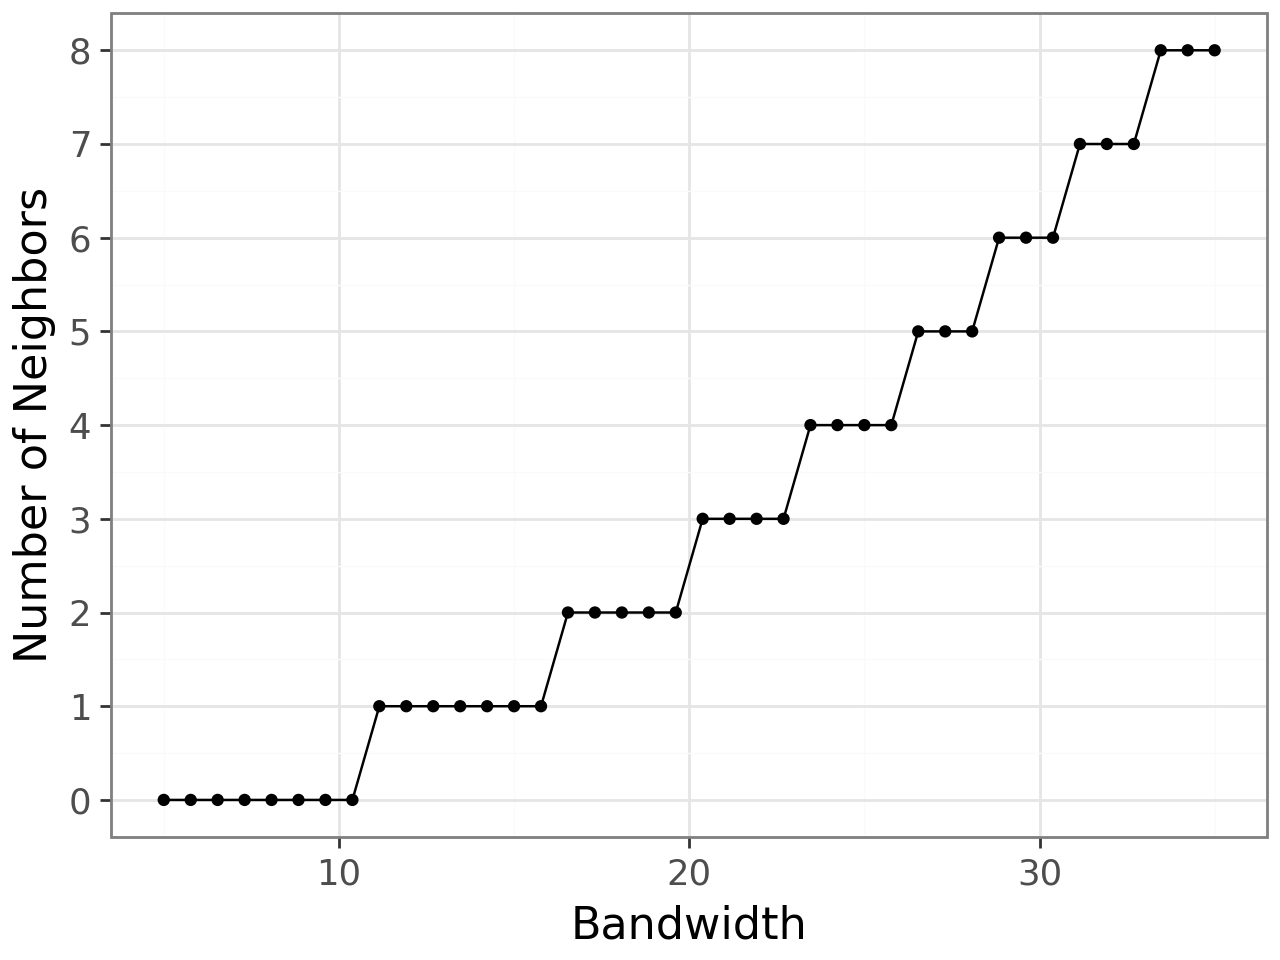

In [8]:
plot, df = li.ut.query_bandwidth(
    coordinates=adata.obsm["X_spatial_coords"],
    start=5,         
    end=35,           
    interval_n=40    
)
plot + scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

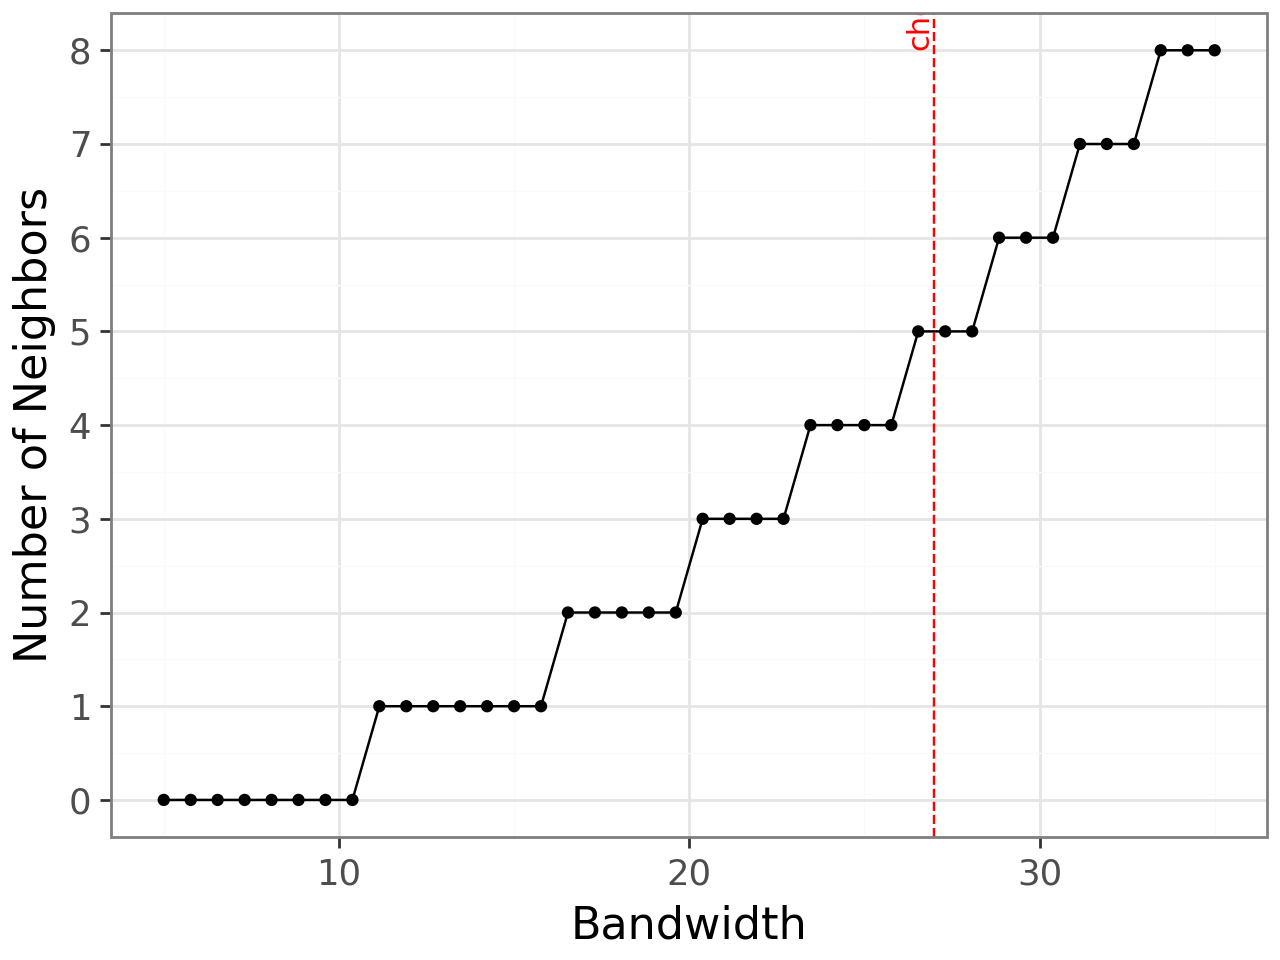

In [10]:
chosen = 27
plot + geom_vline(xintercept=chosen, linetype="dashed", color="red") + \
       annotate("text", x=chosen, y=df.neighbours.max(), 
                label=f"chosen={chosen}µm",
                angle=90, va="bottom", ha="right", color="red") + \
       scale_y_continuous(breaks=range(int(df.neighbours.min()), 
                                       int(df.neighbours.max())+1))

In [9]:
li.ut.spatial_neighbors(adata=adata, bandwidth=27, spatial_key="X_spatial_coords")

### Visualize proximity

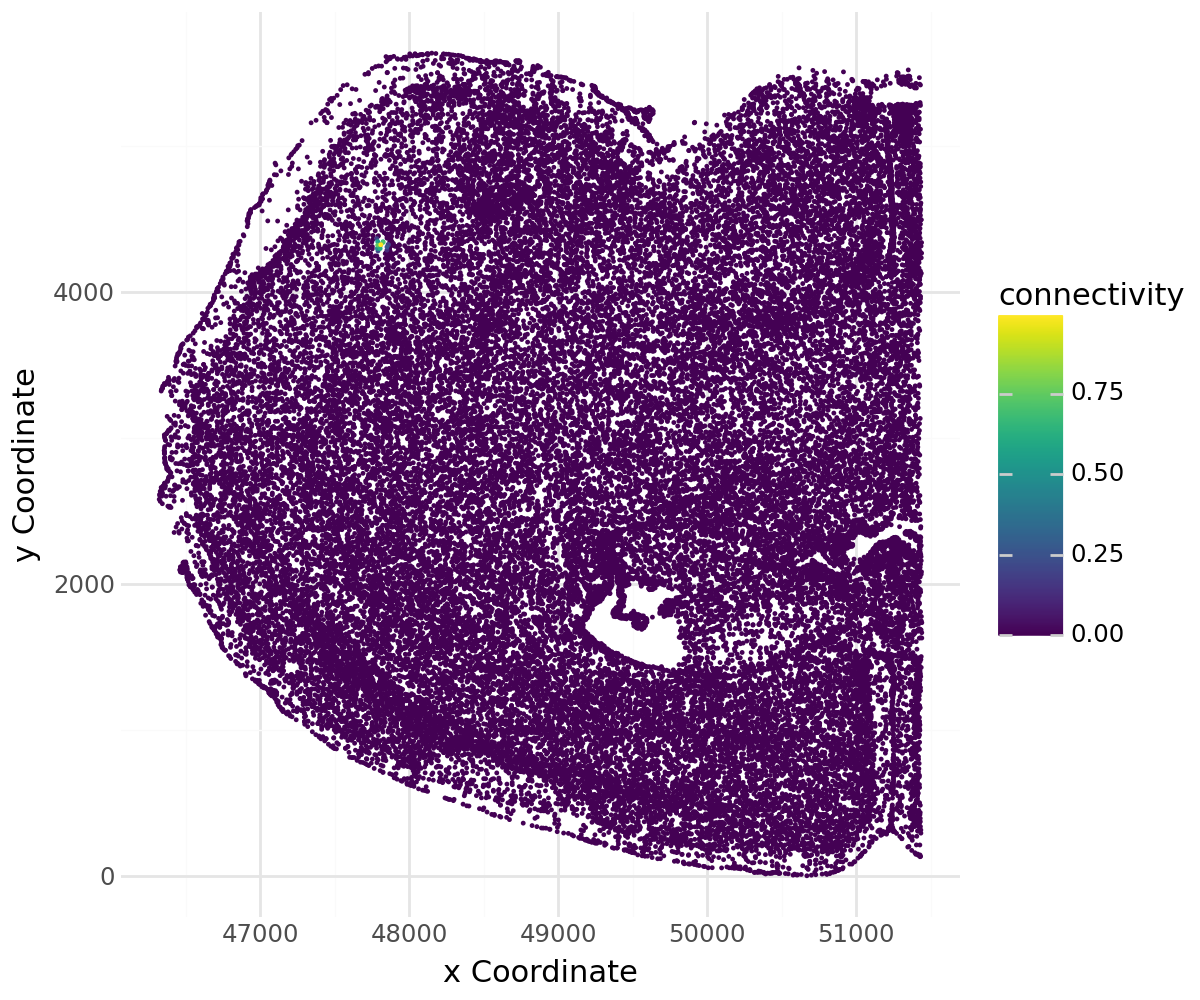

In [10]:
li.pl.connectivity(adata, idx=7000, size=0.01, figure_size=(6, 5), spatial_key="X_spatial_coords")

## Find spatially variable genes (SVGs) using Morans'I

In [11]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, 
                       show_progress_bar=True)

In [12]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
Slc17a7,0.641460,0.000000,0.000003,0.000000
Shox2,0.466922,0.000000,0.000003,0.000000
Baiap3,0.462926,0.000000,0.000003,0.000000
Calb2,0.451540,0.000000,0.000003,0.000000
Neurod2,0.449919,0.000000,0.000003,0.000000
...,...,...,...,...
Slc6a5,-0.000286,0.435524,0.000003,0.435912
A630012P03Rik,-0.000416,0.404658,0.000003,0.406106
Cubn,-0.000601,0.361544,0.000003,0.363487
Arhgef38,-0.000698,0.339470,0.000003,0.341908


## Check spatially variable genes (SVGs)

In [13]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

1028

![SVGs_options](../_static/SVGs_plot.png)

### Option1: filter by SVGs 
Filtering your adata by SVGs (Spatially Variable Genes) means selecting only those LR interactions where BOTH the ligand and the receptor genes show spatial variability.
<br>

Keep in mind that applying this filter may reduce the number of detected LR pairs, possibly excluding biologically meaningful interactions where only one partner is spatially variable.
<br>

**In this tutorial, we will use this filter for faster calculations**
</br>

In [14]:
adata = adata[:, svgs]

### Option2: filter by SVGs and their pair
This option filters out ligand–receptor (LR) pairs only when neither the ligand nor the receptor is spatially variable. <br>
In this mode we need to load LR database to find SVGs pairs.

#### Get LR database

- **Mouse**? Convert LR database to mouse gene symbol

In [15]:
resource = li.rs.select_resource('consensus')
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})
# We will then translate
lr = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
lr
lr.tuples = list(zip(lr["ligand"], lr["receptor"]))

/g/stegle/aalsayah/repos/liana-py/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
/scratch/jobs/42958790/ipykernel_3205363/4129519995.py:17: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access


- **Human**? use the below code:

In [23]:
#retrive LR database
lr = li.rs.select_resource()

#### Filter by SVGs and their pairs

In [19]:
#Find SVGs
svgs_df = adata.uns['moranI'][(adata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (adata.uns['moranI']['I'] > 0.01)].index.tolist()

In [20]:
#Filter LR database to keep only SVGs
filtered_lr = lr[
    lr['ligand'].isin(svgs_df) |
    lr['receptor'].isin(svgs_df)
]

In [21]:
all_genes_and_complexes = pd.unique(
    filtered_lr[['ligand', 'receptor']].values.ravel()
).tolist()

In [22]:
adata_var_names = adata.var_names.tolist()

In [23]:
genes_to_keep = [
    gene for gene in all_genes_and_complexes
    if gene in adata_var_names
]

In [24]:
adata = adata[:, genes_to_keep].copy()

## Compute inflow score 

In [16]:
lrdata = li.mt.inflow(adata,  
                                  groupby='cell_type', # cell type columns        
                                  interactions=lr.tuples,         #if human, just use: 'cellchatdb'                 
                                  use_raw=False)
                                  
lrdata.shape

/home/alsayah/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.


(49111, 1576)

### Find global score

In [17]:
li.mt.compute_global_score(lrdata, groupby='cell_type')

Running 500 permutations in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:   22.9s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:   28.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   31.1s finished
/g/stegle/aalsayah/repos/liana-py/liana/method/sc/_compute_global_score.py:217: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.


In [21]:
lrdata.uns["global_score"].sort_values('lr_mean').tail()

,ligand,ligand_complex,receptor,receptor_complex,source,target,lr_mean,pval
22992,Efna5,Efna5,Epha6,Epha6,GABAergic neuron,dopaminergic neuron,2.466218,0.001996
21577,Efna5,Efna5,Epha10,Epha10,glutamatergic neuron,glutamatergic neuron,2.531825,0.001996
16873,Hgf,Hgf,Cd44,Cd44,glutamatergic neuron,monocyte,2.557157,0.003992
21548,Efna5,Efna5,Epha4,Epha4,glutamatergic neuron,glutamatergic neuron,2.879788,0.001996
24878,Col18a1,Col18a1,Gpc4,Gpc4,choroid plexus epithelial cell,choroid plexus epithelial cell,3.577656,0.001996


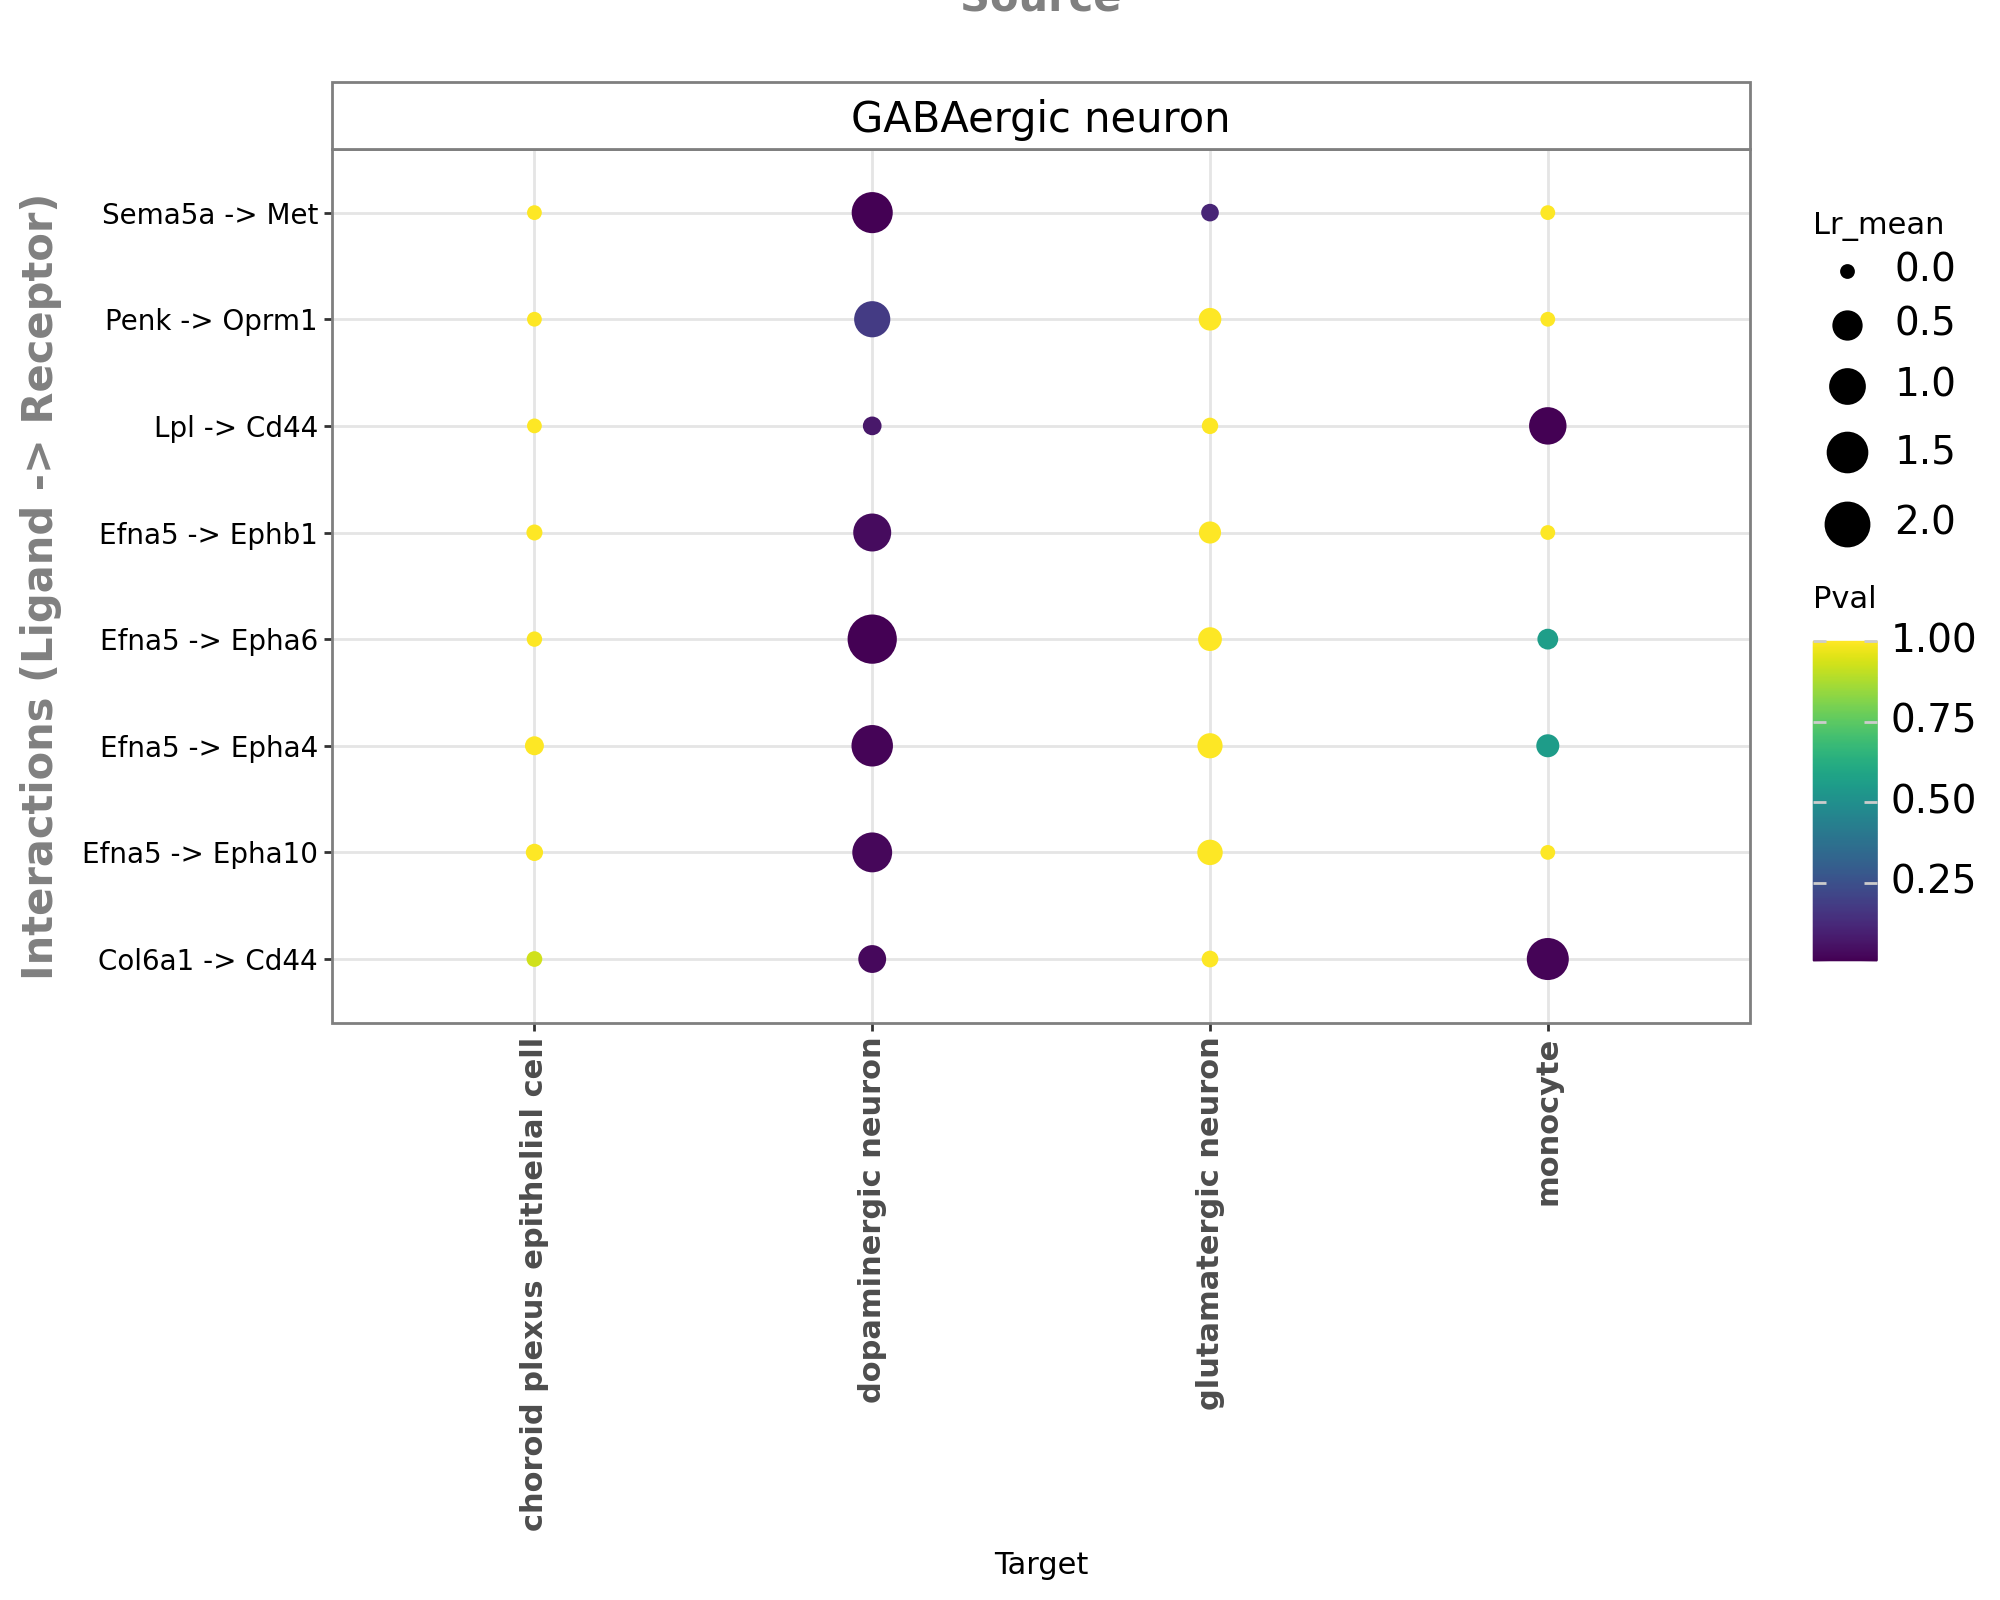

In [22]:
li.pl.dotplot(adata = lrdata, 
              colour='pval',
              size = "lr_mean",
              source_labels=['GABAergic neuron'],
              target_labels=['dopaminergic neuron', "choroid plexus epithelial cell", "monocyte", "glutamatergic neuron"],
              filter_fun=lambda x: x['lr_mean'] > 0.5,
              figure_size=(10, 8),
              uns_key='global_score' 
             )

## Optional: filter data to keep only spatially variable LR interaction

In [18]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [19]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

1267

In [20]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
GABAergic neuron^Efna5^Epha10,0.438071,0.0,0.000003,0.0
glutamatergic neuron^Gnb3^Gabbr2,0.469363,0.0,0.000003,0.0
lymphocyte^Efna5^Epha10,0.471731,0.0,0.000003,0.0
glutamatergic neuron^Efna5^Epha10,0.478272,0.0,0.000003,0.0
neuroblast (sensu Vertebrata)^Ntf3^Ntrk3,0.520805,0.0,0.000003,0.0
choroid plexus epithelial cell^Col18a1^Gpc4,0.523843,0.0,0.000003,0.0
GABAergic neuron^Gnb3^Gabbr2,0.527100,0.0,0.000003,0.0
glutamatergic neuron^Efna5^Epha4,0.567840,0.0,0.000003,0.0
glutamatergic neuron^Ntf3^Ntrk3,0.569121,0.0,0.000003,0.0
GABAergic neuron^Vegfc^Vipr2,0.599967,0.0,0.000003,0.0


# Visualizations

### Single Interaction

In [21]:
interaction = "GABAergic neuron^Efna5^Epha10"
parts = interaction.split("^")
cell_type_col = "cell_type"
comp = interaction.split("^")
spatial_key = "X_spatial_coords"

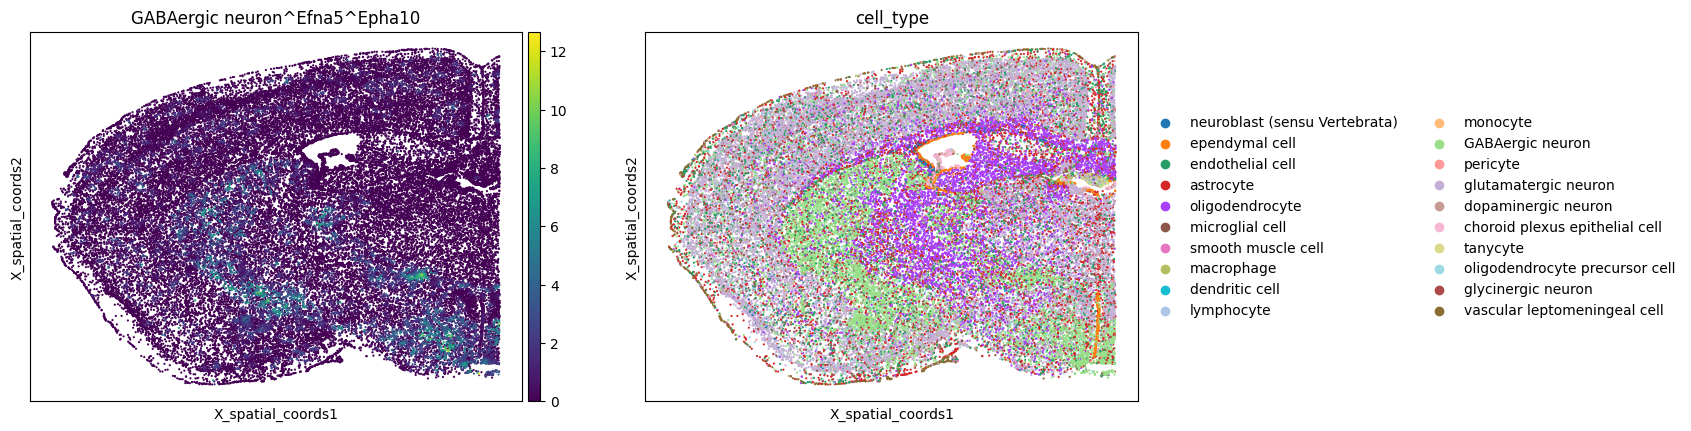

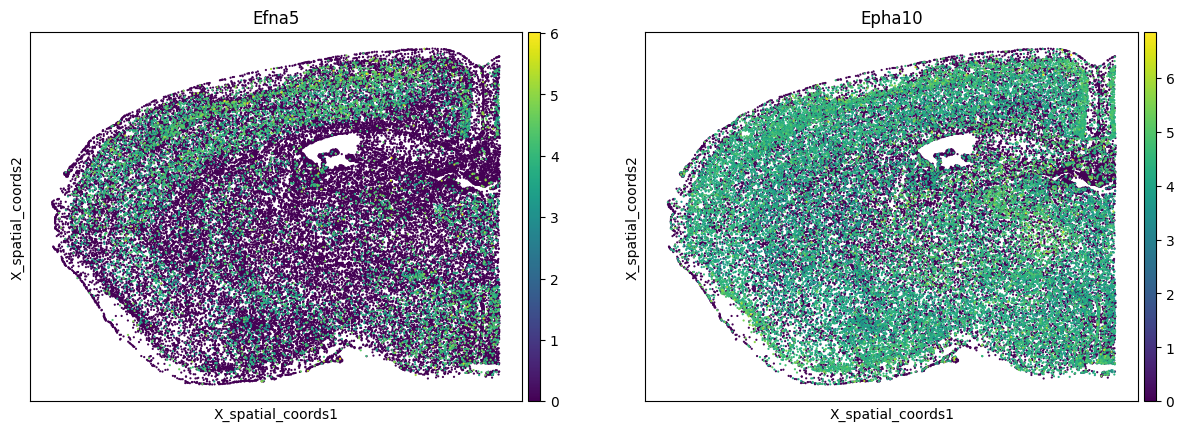

In [22]:
sc.pl.embedding(
    lrdata,
    basis=spatial_key,
    color=[interaction, cell_type_col],
    s=10,
    ncols=2
)

sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=[parts[1], parts[2]],
    s=10,
    use_raw=False,
    ncols=2
)

### Rank reciver cells types 

/scratch/jobs/42526839/ipykernel_2379069/1267648651.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/42526839/ipykernel_2379069/1267648651.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/scratch/jobs/42526839/ipykernel_2379069/1267648651.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


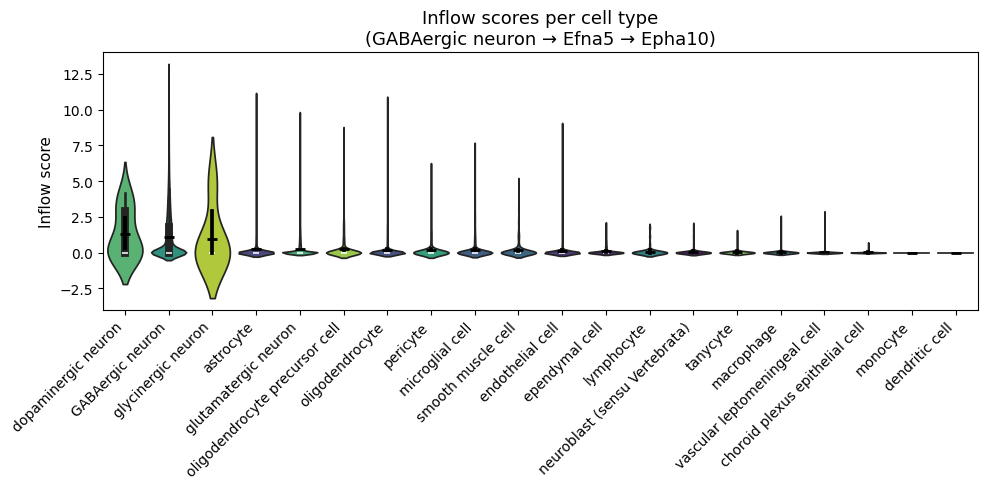

In [ ]:
# --- Data preparation ---
df = pd.DataFrame({
    "cell_type": lrdata.obs[cell_type_col],
    "inflow_score": lrdata[:, interaction].X.toarray().flatten()
}).dropna()

#sort by mean inflow
order = df.groupby("cell_type")["inflow_score"].mean().sort_values(ascending=False).index

# --- Statistical summary ---
means = df.groupby("cell_type")["inflow_score"].mean()
stds = df.groupby("cell_type")["inflow_score"].std()
summary = pd.DataFrame({"mean": means, "std": stds})

# --- Plot ---
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x="cell_type", y="inflow_score",
    inner="box", density_norm="width",
    order=order,
    hue="cell_type", legend=False,
    palette="viridis"
)
sns.pointplot(
    data=df, x="cell_type", y="inflow_score",
    order=order,
    estimator=np.mean, errorbar=('ci', 95),
    color="black",  markers="_", linestyle="none"
)
plt.xticks(rotation=45, ha="right")
plt.title(f"Inflow scores per cell type\n({interaction.replace('^', ' → ')})", fontsize=13)
plt.ylabel("Inflow score", fontsize=11)
plt.xlabel("")
plt.grid(axis="y", linestyle="none", alpha=0.4)
plt.tight_layout()
plt.show()

### Single Interaction by Regions

/g/stegle/aalsayah/repos/liana-py/liana/plotting/_plot_spatial_inflow_score_single_interaction.py:410: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


(<Figure size 1000x800 with 5 Axes>,
 <Axes: title={'center': 'GABAergic neuron^Efna5^Epha10 score by cell type'}>)

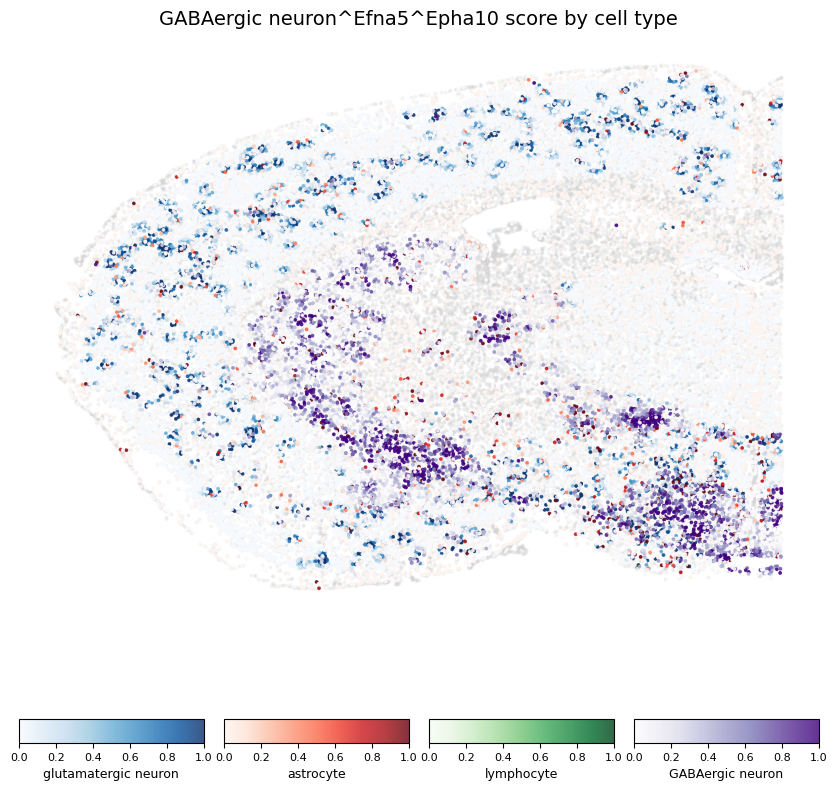

In [105]:
plot_spatial_inflow_score_single_interaction(
    adata=lrdata,
    spatial_key="X_spatial_coords",
    interaction="GABAergic neuron^Efna5^Epha10",
    obs_key="cell_type",
    percentile_scaling = (5,95),
    labels=["glutamatergic neuron", "astrocyte",  "lymphocyte", "GABAergic neuron"],
    colorbar_layout='bottom',
    show_counts=False)

### Single Interaction by Regions

(<Figure size 1000x800 with 5 Axes>,
 <Axes: title={'center': 'GABAergic neuron^Efna5^Epha10 score by cell type'}>)

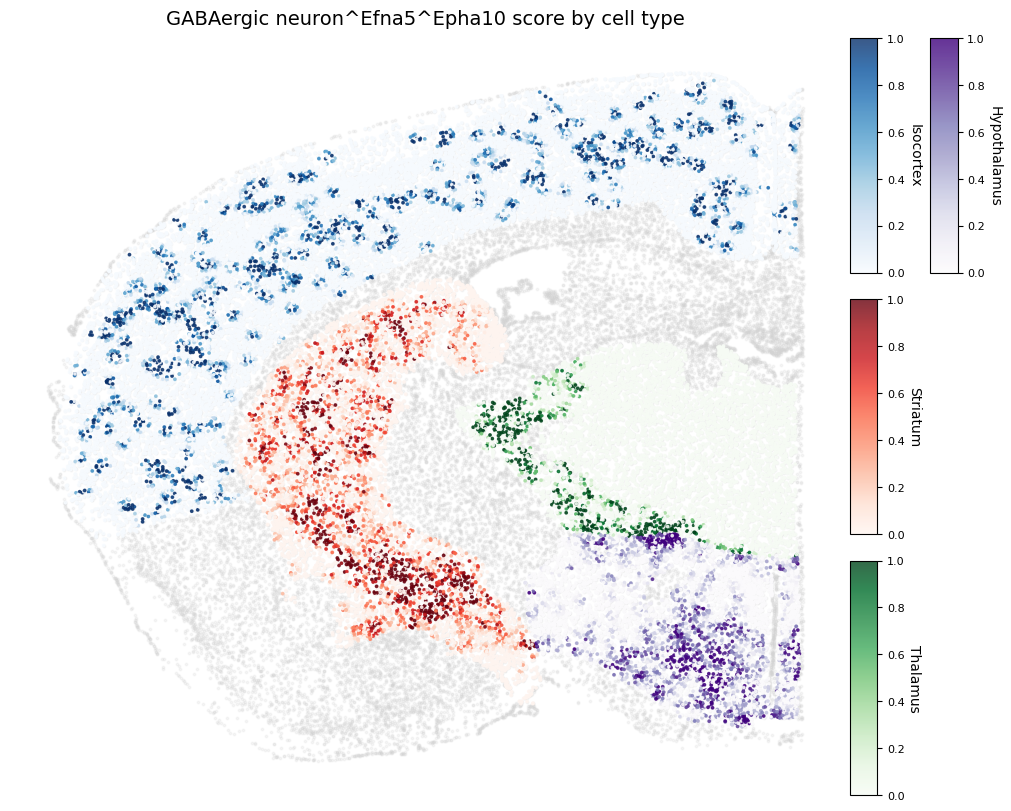

In [107]:
plot_spatial_inflow_score_single_interaction(
    adata=lrdata,
    spatial_key="X_spatial_coords",
    interaction="GABAergic neuron^Efna5^Epha10",
    obs_key="major_brain_region",
    percentile_scaling = (5,95),
    labels=["Isocortex", "Striatum",  "Thalamus", "Hypothalamus"],
    colorbar_layout='side',
    show_counts=False)

### Heatmap of single interaction flow (cell types)

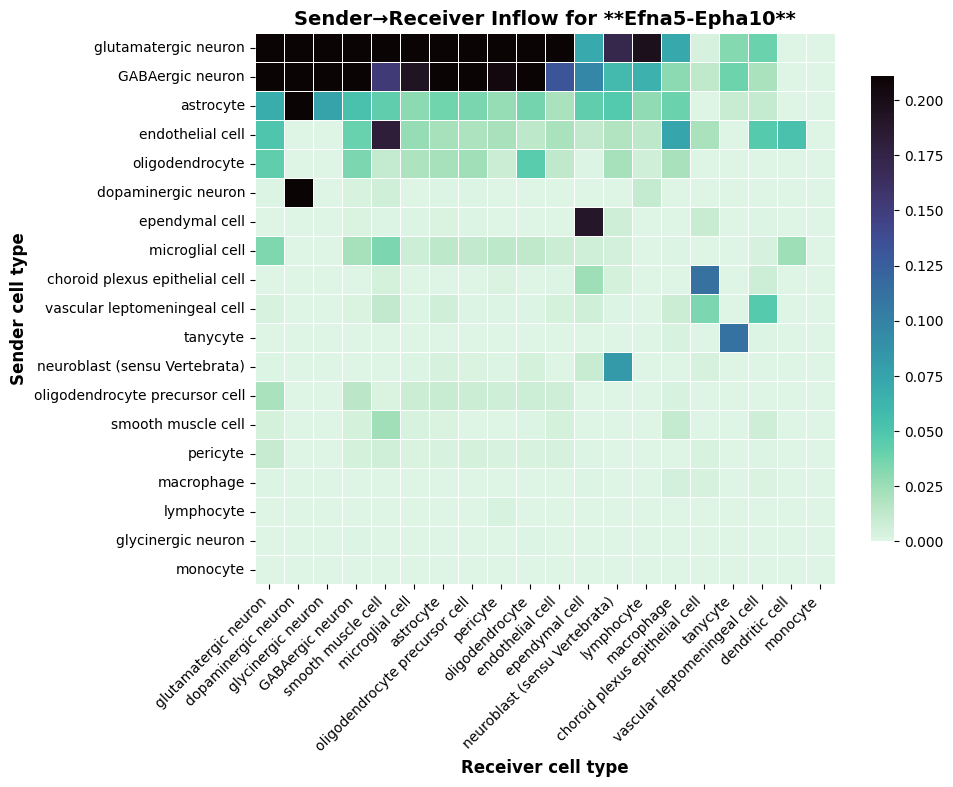

In [171]:
df = lr_heatmap(
    ligand="Efna5",
    receptor="Epha10",
    lrdata=lrdata,
    groupby="cell_type"    
)

### Heatmap of single interaction flow (regions)

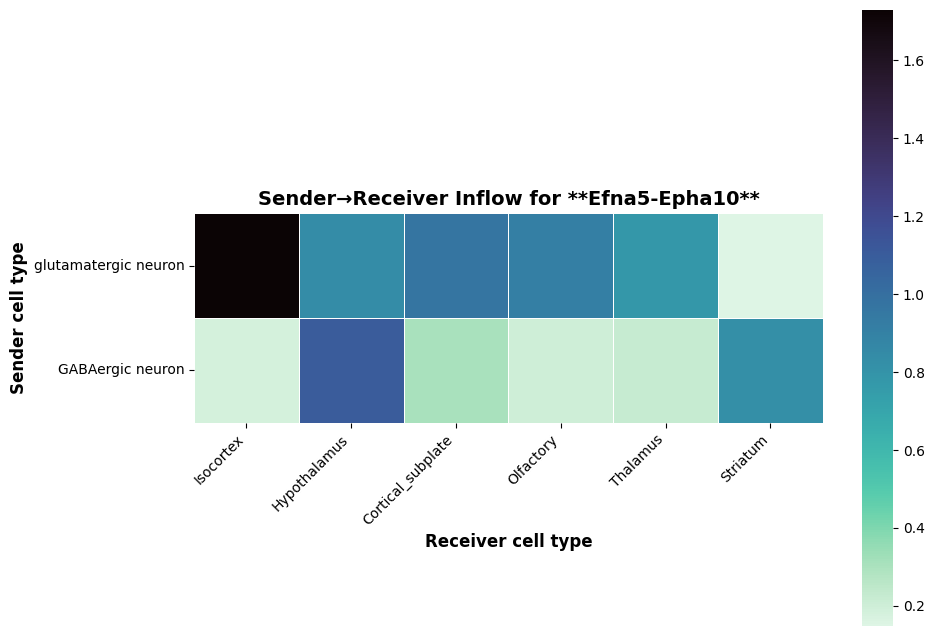

In [172]:
df = lr_heatmap(
    ligand="Efna5",
    receptor="Epha10",
    lrdata=lrdata,
    filter_min_mean=0.05,
    groupby="major_brain_region"    
)

### Spatial Flow Field 

This visualization shows the **spatial gradient of inflow scores** for the interaction.

- The **background color** represents the inflow intensity (how much receptor-expressing cells are influenced by nearby ligands).  
- The **white arrows** indicate the *direction* of maximum inflow increase. Showing the "flow" of ligand influence through space.  

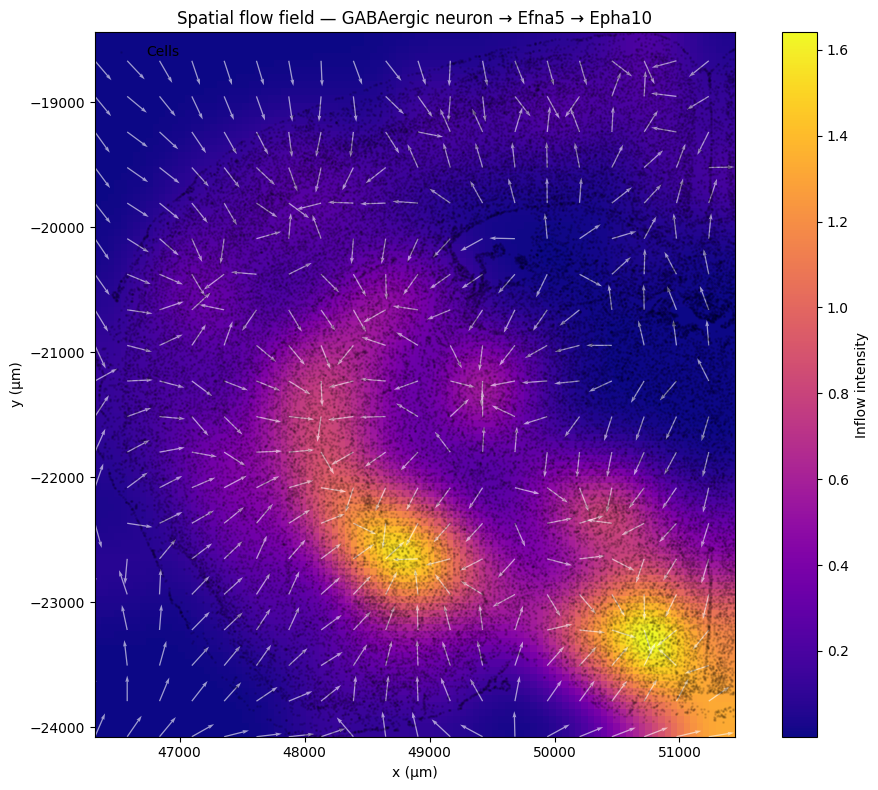

In [87]:
from scipy.ndimage import gaussian_filter

# Extract coordinates and inflow
coords = lrdata.obsm[spatial_key]
inflow_vals = lrdata[:, interaction].X.toarray().flatten()

# Create a smooth inflow intensity field
nbins = 100
x = np.linspace(coords[:,0].min(), coords[:,0].max(), nbins)
y = np.linspace(coords[:,1].min(), coords[:,1].max(), nbins)
X, Y = np.meshgrid(x, y)

# Interpolate inflow scores onto grid (simple method)
from scipy.interpolate import griddata
Z = griddata(coords, inflow_vals, (X, Y), method="nearest") 
Z_smooth = gaussian_filter(Z, sigma=5)

# Compute gradients (approximate inflow direction)
dy, dx = np.gradient(Z_smooth)

plt.figure(figsize=(10, 8))

plt.imshow(
    Z_smooth,
    extent=(x.min(), x.max(), y.min(), y.max()),
    origin="lower",
    cmap="plasma",
)

norm = np.sqrt(dx**2 + dy**2)
dxn, dyn = dx / (norm + 1e-9), dy / (norm + 1e-9)
plt.quiver(X[::5, ::5], Y[::5, ::5], dxn[::5, ::5], dyn[::5, ::5],
           color="white", alpha=0.6, scale=25, width=0.002)
im = plt.imshow(Z_smooth, extent=(x.min(), x.max(), y.min(), y.max()),
                origin="lower", cmap="plasma")
plt.colorbar(im, label="Inflow intensity")
plt.title(f"Spatial flow field — {interaction.replace('^', ' → ')}", fontsize=12)
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.tight_layout()
plt.scatter(coords[:,0], coords[:,1], s=1, c="black", alpha=0.1, label="Cells")
plt.legend(frameon=False)

plt.show()


### Global score per region

In [34]:
niche_label = "major_brain_region"
cell_type_col = "cell_type"

In [ ]:
interaction = "GABAergic neuron^Efna5^Epha10"
parts = interaction.split("^")
comp = interaction.split("^")
spatial_key = "X_spatial_coords"

In [35]:
lrdata.obs["group_labels"] = lrdata.obs[cell_type_col].astype(str) + "::" + lrdata.obs[niche_label].astype(str)
li.mt.compute_global_score(lrdata=lrdata, groupby= "group_labels")

/scratch/jobs/42526839/ipykernel_2378653/1710454414.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


Running 500 permutations in parallel...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 280 tasks      | elapsed:   27.6s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:   43.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   48.7s finished


In [36]:
lrdata.uns["global_score"][["target", "niche"]] =lrdata.uns["global_score"]["target"].str.split("::", expand=True)
cols = [c for c in lrdata.uns["global_score"].columns if c not in ["lr_mean", "pval"]]
cols += ["lr_mean", "pval"]
lrdata.uns["global_score"] = lrdata.uns["global_score"][cols]

In [37]:
lrdata.uns["global_score"].sort_values("pval")

,ligand,ligand_complex,receptor,receptor_complex,source,target,niche,lr_mean,pval
145627,Vcan,Vcan,Egfr,Egfr,choroid plexus epithelial cell,neuroblast (sensu Vertebrata),Striatum,0.030124,0.001996
4052,Ntf3,Ntf3,Ntrk3,Ntrk3,GABAergic neuron,GABAergic neuron,Hypothalamus,0.137592,0.001996
4051,Efna5,Efna5,Epha4,Epha4,GABAergic neuron,GABAergic neuron,Hypothalamus,1.256914,0.001996
4050,Efna5,Efna5,Epha10,Epha10,GABAergic neuron,GABAergic neuron,Hypothalamus,1.845342,0.001996
4044,Gnb3,Gnb3,Gabbr2,Gabbr2,GABAergic neuron,GABAergic neuron,Hypothalamus,0.888546,0.001996
...,...,...,...,...,...,...,...,...,...
5,Ntf3,Ntf3,Ntrk3,Ntrk3,neuroblast (sensu Vertebrata),GABAergic neuron,Cortical_subplate,0.000000,1.000000
228987,Col14a1,Col14a1,Cd44,Cd44,microglial cell,vascular leptomeningeal cell,nan,0.000000,1.000000
4,Col18a1,Col18a1,Gpc4,Gpc4,choroid plexus epithelial cell,GABAergic neuron,Cortical_subplate,0.000000,1.000000
228989,Pthlh,Pthlh,Tshr,Tshr,choroid plexus epithelial cell,vascular leptomeningeal cell,nan,0.000000,1.000000
